---
title: 'Chapter 1: Fundamentals of Time Series'
jupyter:
  kernelspec:
    display_name: Python (timeSeries-course)
    language: python
    name: timeseries-course
editor_options: 
  chunk_output_type: console
---

## Fundamentals of Time Series

### Topics Covered:

1.  Introduction to Time Series
2.  Dealing with Time Series data in Python
3.  Components of Time Series
4.  Stationarity and Statistical Tests
5.  Time Series Decomposition

------------------------------------------------------------------------

## 1. Introduction to Time Sereies

### 1.1 Formal Definition

A **time series** can be defined as **a collection of observations** indexed according to the order they are obtained in time.

Each observation at time $t$ is modeled as a random variables, ${Y_t}$, and the collection of random variables indexed by $t$ is referred to as a **stochastic process**. $t$ will typically be discrete and vary over the integers numbers or some subset of the integers ($t=1,\ldots,T$).

Then, the **time series** is a **realization** (observed values) of the stochastic process. However, we may use the term time series in general to refer to the realization of the stochastic process or to stochastic process itself.

![Stochstic process](./Figures/plot0.png){#fig-id fig-align="center" width="100%"}

-   The complete probabilistic structure of a stochastic process is determined by the set of distributions of all finite collections of the Y’s.

-   Fortunately, we will not have to deal explicitly with these multivariate distributions.

-   Much of the information in these joint distributions can be described in terms of means, variances, and covariances.

-   Consequently, we concentrate our efforts on these first and second moments. (If the joint distributions of the X’s are multivariate normal distributions, then the first and second moments completely determine all the joint distributions.)

### 1.2 Stochastic Process: means, variances and covariances

For a stochastic process ${Y_t: t=0, \pm 1, \pm 2, \ldots}$

The **mean function:**

$\mu_t=E(Y_t)$

The **variance function:**

$\sigma^2_t=E[(Y_t-\mu_t)^2]$

Note that $\mu_t, \sigma^2_t$ are the mean (expected value) and the variance of the process at time $t$. In general, $\mu_t$ and $\sigma^2_t$ can be different at each time point $t$.

The **autocovariance function** for two time points $t$ and $s$:

$\gamma_{t,s}=\text{Cov}(Y_t, Y_s)$ where $\text{Cov}(Y_t, Y_s)=E[(Y_t-\mu_t)(Y_s-\mu_s)]= E(Y_t Y_s)-\mu_t\mu_s$.

The **autocorrelation function** for two time points $t$ and $s$:

$\rho_{t,s}=\text{Corr}(Y_t, Y_s)$ where $\text{Corr}(Y_t, Y_s)=\frac{\text{Cov}(Y_t,Y_s)}{\sqrt{\text{var}(Y_t)\text{var}(Y_s)}}$

Recall that both covariance and correlation are measures of the (linear) dependence between random variables but that the correlation is somewhat easier to interpret (because always takes values between -1 and 1).

-   Some properties of the covariance
    -   $\gamma_{t,t}= \text{var}(Y_t), \quad \rho_{t,t}=1$

    -   $\gamma_{t,s}= \gamma_{s,t}, \quad \rho_{t,s}=\rho_{s,t}$

    -   $|\gamma_{t,s}| \leq \sqrt{\gamma_{t,t}\gamma_{s,s}}, \quad  |\rho_{t,s}|\leq 1$

Values of $\rho_{t,s}$ near $\pm1$ indicate strong (linear) dependence, whereas values near zero indicate weak (linear) dependence. If $\rho_{t,s}=0$ , we say that $Y_t$ and $Y_s$ are (linearly) *uncorrelated*.

The **partial autocorrelation function (PACF)** at lag $h$, denoted $\phi_h$​, measures the correlation between $Y_t$ ​ and $Y_{t-h}$ after removing the linear dependence on the intermediate observations $Y_{t−1},Y_{t−2},\dots,Y_{t−h+1}$

Formally, $ϕ_h$​ is the coefficient of $Y_{t-h}$ in the autoregression:

$$
Y_t=\phi_1Y_{t−1}+\phi_2 Y_{t−2}+\ldots+\phi_{h}Y_{t−h}+e_t
$$

Note that $\phi_{1} = \rho_1$ ​(at lag 1, there are no intermediate values to control for). The PACF is particularly useful for identifying the order of autoregressive processes: for an AR(p) process, the PACF cuts off sharply after lag $p$.

A direct consequence from the definition: $c_{1}, c_{2}, \ldots, c_{m}$ and $d_{1}, d_{2}, \ldots, d_{n}$ are constants and $t_{1}$, $t_{2}, \ldots, t_{m}$ and $s_{1}, s_{2}, \ldots, s_{n}$ are time points, then $$
\operatorname{Cov}\left[\sum_{i=1}^{m} c_{i} Y_{t_{i}}, \sum_{j=1}^{n} d_{j} Y_{s_{j}}\right]=\sum_{i=1}^{m} \sum_{j=1}^{n} c_{i} d_{j} \operatorname{Cov}\left(Y_{t_{i}}, Y_{s_{j}}\right)
$$

### 1.3. Key Characteristics of time series data:

-   Temporal ordering matters
-   Temporal dependence between observations
-   Serial correlation (autocorrelation)

### 1.4. Applications:

-   Finance: Stock prices, trading volumes
-   Weather: Temperature, precipitation
-   Healthcare: Patient vitals, disease spread
-   IoT: Sensor data, energy consumption

## 2 Dealing with time series data in Python

The standard for handling time series data in Python is using pandas Series objects. To properly function as a time series, the Series requires a DatetimeIndex.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import skforecast
from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


### 2.1. Load and check data

The package `skforecst` includes some time series data as examples. We will use the `h2o` dataset that contains a monthly expenditure (in \$AUD) on corticosteroid drugs that the Australian health system had between 1991 and 2008.

In [53]:
# Data download
# ==============================================================================
data = fetch_dataset(name='h2o', raw=True)
data.head(5)
# Data preparation
# ==============================================================================
# Modify the data type to the Year-Month-Day date format to use it as the identifier
data['fecha'] = pd.to_datetime(data['fecha'], format='%Y-%m-%d')
# set the date as the field identifier for the series
data = data.set_index('fecha')
data.head(5)

╭────────────────────────────────────── h2o ───────────────────────────────────────╮
│ Description:                                                                     │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health    │
│ system had between 1991 and 2008.                                                │
│                                                                                  │
│ Source:                                                                          │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice(3rd        │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,https://github.com/robjhyndman │
│ /fpp3package, http://OTexts.com/fpp3.                                            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/h2o.csv                                                       │
│                                                                                  │
│ Shape: 204 rows x 2 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

,x
fecha,
1991-07-01,0.429795
1991-08-01,0.400906
1991-09-01,0.432159
1991-10-01,0.492543
1991-11-01,0.502369


For the time series, the data must be observed at time instances $t=1,...,T$. This represents the observation frequency, which is typically assumed to be a regular frequency (e.g., minutes, hours, days, months, quarters, years, etc.). We can select the data from the series at regular time intervals by fixing the frequency. For instance, if we establish a monthly frequency, the data from the first day of each month is collected. If multiple observations exist for that specific day, the first observation is selected, and if no data is available in the series for that day, the corresponding value is set to `Na` (Not Available).

In [54]:
data = data.asfreq('MS')
# we can order by date
data = data.sort_index()
data.head(5)
# Check for missing values
# ==============================================================================
print(f'Number of instances with Na values: {data.isna().any(axis=1).sum()}')

Number of instances with Na values: 0


In this case, it is not necessary since we select the data by monthly frequency, but in general, we can verify that the time index is complete:

In [55]:
start_date = data.index.min()
end_date = data.index.max()
complete_date_range = pd.date_range(start=start_date, end=end_date, freq=data.index.freq)
is_index_complete = (data.index == complete_date_range).all()
print(f"Index complete: {is_index_complete}")

Index complete: True


### 2.2. Plot data

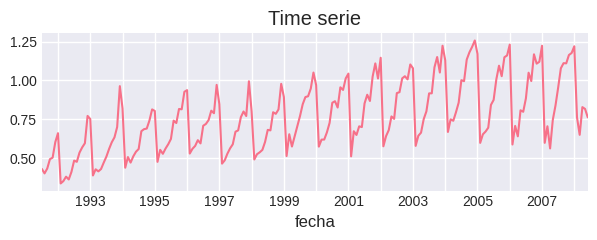

In [56]:
#set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
data['x'].plot(ax=ax)
ax.set_title("Time serie")
plt.tight_layout() 
plt.show()

Some time, when fitting models, we need to split the data into train and test sets. For instance we select for testing the last 2 years (24 months) and use for training the rest of the data:

Train dates : 1991-07-01 00:00:00 --- 2006-06-01 00:00:00  (n=180)
Test dates  : 2006-07-01 00:00:00 --- 2008-06-01 00:00:00  (n=24)


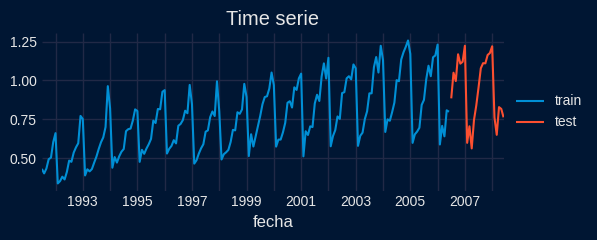

In [57]:
# Split data into train-test
# ==============================================================================
test = 24
data_train = data[:-test] # data[:-test+1]
data_test  = data[-test:]
print(
    f"Train dates : {data_train.index.min()} --- "
    f"{data_train.index.max()}  (n={len(data_train)})"
)
print(
    f"Test dates  : {data_test.index.min()} --- "
    f"{data_test.index.max()}  (n={len(data_test)})"
)

set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
data_train['x'].plot(ax=ax, label='train')
data_test['x'].plot(ax=ax, label='test')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie")
plt.tight_layout() 
plt.show()

### 2.3. Dealing with missing data (Na)

If the time series is not complete (there are `Na` values) `pandas` provides tools to impute missing values implementing different strategies.

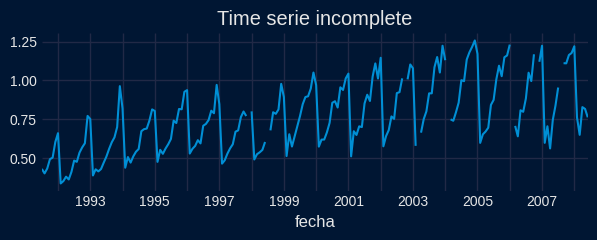

In [58]:
## simulate incomplete data
data_incomplete = data.copy()
# remove 15 values at random
random_indices = np.random.choice(data_incomplete.index, size=8, replace=False)

# set these values to NaN
data_incomplete.loc[random_indices, 'x'] = np.nan
set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
data_incomplete['x'].plot(ax=ax)
ax.set_title("Time serie incomplete")
plt.tight_layout() 
plt.show()

-   Forward fill imputation: copy the last observed value to fill the `Na`.

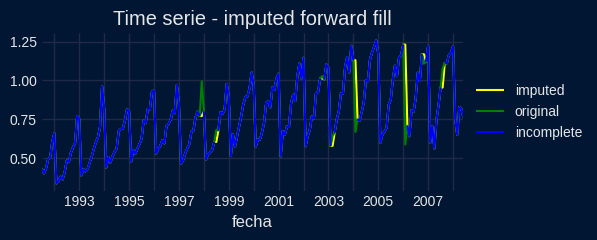

In [59]:
data_imputed = data_incomplete.copy()
data_imputed['x'] = data_imputed['x'].ffill()
fig, ax = plt.subplots(figsize=(6, 2.5))
data_imputed['x'].plot(ax=ax, label='imputed', color="yellow")
data['x'].plot(ax=ax, label='original',color="green")
data_incomplete['x'].plot(ax=ax, label="incomplete", color="blue")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie - imputed forward fill")
plt.tight_layout() 
plt.show()

-   Backward fill imputation: copy the next observed value to fill the `Na`.

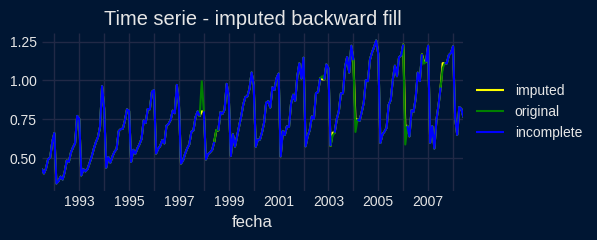

In [60]:
data_imputed = data_incomplete.copy()
data_imputed['x'] = data_imputed['x'].bfill()
fig, ax = plt.subplots(figsize=(6, 2.5))
data_imputed['x'].plot(ax=ax, label='imputed', color="yellow")
data['x'].plot(ax=ax, label='original',color="green")
data_incomplete['x'].plot(ax=ax, label="incomplete", color="blue")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie - imputed backward fill")
plt.tight_layout() 
plt.show()

-   Linear interpolation imputation: This is one of the most common methods for imputing missing values. It involves interpolating between the previous known value and the next known value.

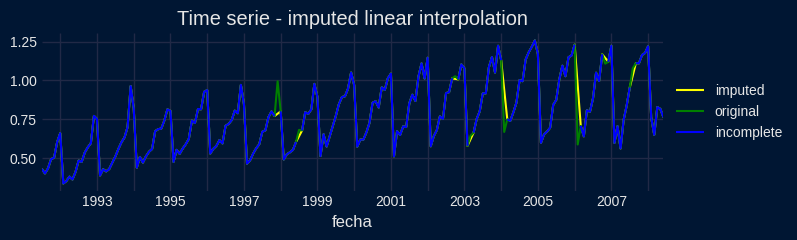

In [61]:
data_imputed = data_incomplete.copy()
data_imputed['x'] = data_imputed['x'].interpolate(method="linear")
fig, ax = plt.subplots(figsize=(8, 2.5))
data_imputed['x'].plot(ax=ax, label='imputed', color="yellow")
data['x'].plot(ax=ax, label='original',color="green")
data_incomplete['x'].plot(ax=ax, label="incomplete", color="blue")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie - imputed linear interpolation")
plt.tight_layout() 
plt.show()

Pandas interpolation supports several interpolation methods beyond linear interpolation:

```         
help(pd.Series.interpolate)
```

| Method | Brief Description |
|------------------------------------|------------------------------------|
| `linear` | Linear interpolation between known points (default) |
| `time` | Interpolation based on temporal indices (`DatetimeIndex`) |
| `index` | Interpolation based on numeric index (default for numeric indices) |
| `nearest` | Fills with the nearest value (no smoothing) |
| `zero` | Step interpolation (piecewise constant, backward) |
| `slinear` | Smooth linear interpolation (order 1 splines) |
| `quadratic` | Interpolation with quadratic splines |
| `cubic` | Interpolation with cubic splines |
| `polynomial` | Interpolation with polynomials of specified degree |
| `barycentric` | Barycentric interpolation method (numerical) |
| `krogh` | Polynomial interpolation (numerical) |
| `piecewise_polynomial` | Piecewise polynomial interpolation method (deprecated) |
| `pchip` | Interpolation with monotonic splines (shape-preserving) |
| `akima` | Interpolation with Akima method (shape-preserving) |

### 2.4. Reading time series data from files

To read files in excel format you need to install the engine `openpyxl` in your conda environment.

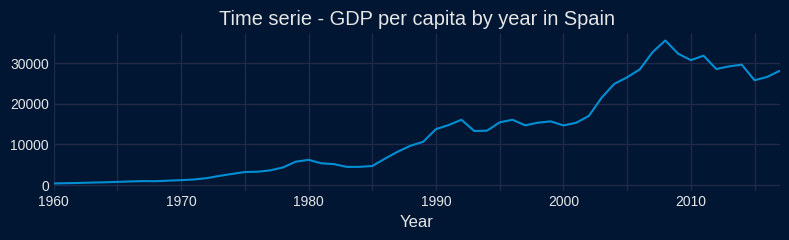

In [62]:
global_economy = pd.read_excel("./Data/global_economy.xlsx", engine="openpyxl")
global_economy.head()
global_economy['Year'] = pd.to_datetime(global_economy['Year'],format='%Y')
global_economy['GDP_PC'] = global_economy['GDP'] / global_economy['Population']

# we can select the time serie for spain
gdp_sp = global_economy[global_economy['Country']=='Spain'][['Year','GDP_PC']]
gdp_sp = gdp_sp.set_index('Year')
# or use the complete DataFrame. However, in this case, year is not unique in the DataFrame
# since we have a data for every country. Better to use multiIndex
global_economy = global_economy.set_index(['Country','Year'])



# Thus we have a time serie for each country
fig, ax = plt.subplots(figsize=(8, 2.5))
global_economy.loc['Spain']['GDP_PC'].plot(ax=ax, label="Spain")
#global_economy.loc['France']['GDP_PC'].plot(ax=ax, label="France")
#global_economy.loc['Portugal']['GDP_PC'].plot(ax=ax, label="Portugal")
#ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie - GDP per capita by year in Spain")
plt.tight_layout() 
plt.show()

### Exercise 1.1

The file `tourism.xlsx` cotains information about quarterly sample-weighted estimates overnight trips from 1998 Q1 to 2016 Q4 across different Australian regions. Obtain the time series data for `Holiday` trips in `Adelaide` region. Use quarterly frequency and check if there are missing data. If missing data are included in the series, impute values using three different interpolation method and compare the obtained results in a plot.

In [63]:
tourism = pd.read_excel("./Data/tourism.xlsx", engine="openpyxl")
tourism.head()

,Quarter,Region,State,Purpose,Trips
0,1998-01-01,Adelaide,South Australia,Business,135.077690
1,1998-04-01,Adelaide,South Australia,Business,109.987316
2,1998-07-01,Adelaide,South Australia,Business,166.034687
3,1998-10-01,Adelaide,South Australia,Business,127.160464
4,1999-01-01,Adelaide,South Australia,Business,137.448533


In [64]:
tourism['Quarter'] = pd.to_datetime(tourism['Quarter'],format='%Y-%m-%d')
tourism = tourism[(tourism['Region']=='Adelaide') & (tourism['Purpose']=='Holiday')]
tourism = tourism.set_index('Quarter')
tourism = tourism.asfreq('QS')
tourism.head()

,Region,State,Purpose,Trips
Quarter,,,,
1998-01-01,Adelaide,South Australia,Holiday,223.557406
1998-04-01,Adelaide,South Australia,Holiday,130.287369
1998-07-01,Adelaide,South Australia,Holiday,156.089398
1998-10-01,Adelaide,South Australia,Holiday,182.328980
1999-01-01,Adelaide,South Australia,Holiday,185.331880


In [65]:
print(f'Number of instances with Na values: {tourism.isna().any(axis=1).sum()}')

Number of instances with Na values: 5


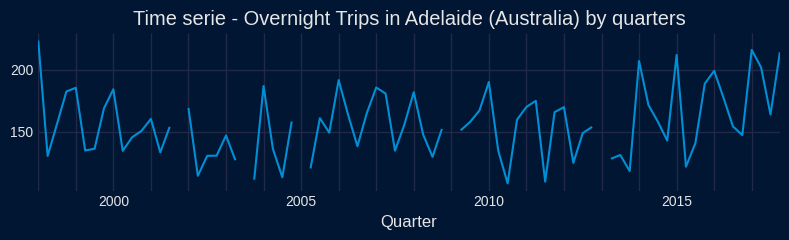

In [66]:
# Thus we have a time serie for each country
fig, ax = plt.subplots(figsize=(8, 2.5))
tourism['Trips'].plot(ax=ax)
ax.set_title("Time serie - Overnight Trips in Adelaide (Australia) by quarters")
plt.tight_layout() 
plt.show()

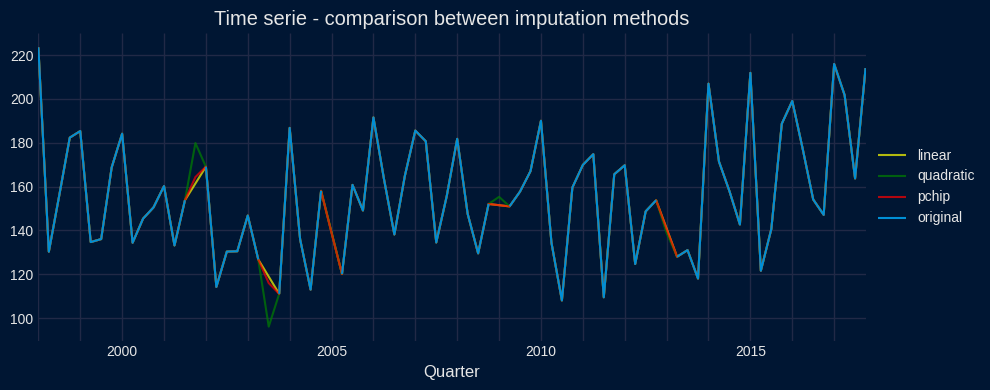

In [67]:
tourism_imputed_linear = tourism.copy()
tourism_imputed_quad = tourism.copy()
tourism_imputed_pchip = tourism.copy()
tourism_imputed_linear['Trips'] = tourism['Trips'].interpolate(method="linear")
tourism_imputed_quad['Trips'] = tourism['Trips'].interpolate(method="quadratic")
tourism_imputed_pchip['Trips'] = tourism['Trips'].interpolate(method="pchip")
fig, ax = plt.subplots(figsize=(10, 4))
tourism_imputed_linear['Trips'].plot(ax=ax, label='linear', color="yellow", alpha=0.7)
tourism_imputed_quad['Trips'].plot(ax=ax, label='quadratic', color="green", alpha=0.7)
tourism_imputed_pchip['Trips'].plot(ax=ax, label='pchip', color="red", alpha=0.7)
tourism['Trips'].plot(ax=ax, label='original')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie - comparison between imputation methods")
plt.tight_layout() 
plt.show()



## 3. Components of Time Series

Time series analysis is based on the premise that observed data is not purely chaotic. Instead, it is the result of superimposing different patterns or sources of variation. Understanding these sources is the first step toward effective predictive modeling.

Formally, we can decompose a time series $Y_t$ into four fundamental components: trend, seasolality, cyclicity and the noise (residual)

### 3.1. Trend ($T_t$)

The trend represents the **long-term** evolution (increasing or decreasing) or direction of the series. It is the smooth, underlying movement of the data, ignoring short-term perturbations.

-   **Types:** A trend does not have to be linear. It can change direction, but it always implies a sustained structural shift.

    -   **Deterministic**: Can be described by a fixed mathematical function
        -   **Linear Trend**: The simplest form of trend, implying a constant amount of increase or decrease per time unit.

            $T_t = \beta_0 + \beta_1 t$

            $\beta_1$ represents the constant rate of change, and $t=1,\ldots,T$ *Examples:* Steady growth, such as simple production lines or short-term sales forecasts where market conditions are stable.

        -   **Polynomial Trend**: Used when the rate of change itself is changing (accelerating or decelerating). A quadratic trend is the most common polynomial.

            $T_t = \beta_0 + \beta_1 t + \beta_2 t^2$

            If $\beta_2 > 0$, the trend curves upwards (accelerating). Polynomials of high degrees ($t^3, t^4...$) should be avoided in forecasting because they tend to explode (go to $\pm \infty$) very quickly at the end of the series, causing overfitting.

            *Examples*: efficiency and learning curves (employee productivity when performing a new repetitive task).

        -   **Exponential Trend**: Used when growth is proportional to the current size of the series (multiplicative growth), rather than a fixed amount.

            $T_t = \beta_0 e^{\beta_1 t}$

            Often seen in finance (compound interest), biology (population growth), or early-stage adoption of technology. It can be transformed into a linear trend by taking the logarithm $\ln(T_t) = \ln(\beta_0) + \beta_1 t$.

            *Examples*: exponential trends occur fundamentally in processes wheregrowth is proportional to the current size. Bacterial growth (if a bacteria colony divides every 20 minutes, the population doubles at each step), compound interest in finance(investing money at a 7% annual return and reinvesting the dividends, wealth grows exponentially).

        -   **Logistic Trend** (S-Curve): Real-world growth rarely continues forever. Systems hit physical limits or market saturation. The logistic curve models an initial exponential growth that slows down as it approaches a maximum capacity ($K$).

            $T_t = \frac{K}{1 + Ae^{-rt}}$

            where $K$ is the carrying capacity (the ceiling), $r$ is the growth rate, and $A$ is a parameter related to the starting point.

            *Examples*: Product lifecycle (intro $\to$ growth $\to$ maturity), epidemiology, or market saturation.

    ![Types of deterministic trends](./Figures/deterministic_trend.png)

    -   ***Stochastic**:* Unlike deterministic trends, a *stochastic trend* does not follow a pre-defined path fixed in time. Instead, the trend itself evolves randomly. The most common model for this is the *random walk with drift*.

        $Y_t = \mu + Y_{t-1} + \epsilon_t$

        Where $\mu$ is the "drift" (average growth per period, similar to the slope), $Y_{t-1}$ is the value of the series at the previous step, and $\epsilon_t$ is a white noise error \[usually $\epsilon_t\sim N(0,\sigma)$\]

The difference between deterministic and stochastic trends is how the process reacts to an unexpected event (shock). In deterministic trend the expected value "follow" the trend, and the series is expected to revert to the trend line after a shock. By contrast, in a stochastic trend, the current value depends entirely on the previous value, therefore, when a shock is observed the series continues evolving from that new point.

![](Figures/deterministic-vs-stochasticTrend.png)

### 3.2. Seasonality ($S_t$)

Seasonality refers to predictable patterns that repeat over a fixed and known period of time. Unlike cyclical trends, which are driven by complex and irregular economic forces, seasonality is strictly bound to the calendar or the clock.

The defining feature of seasonality is the **frequency** or **period** (denoted as $m$). This is the number of observations required for the pattern to complete one full cycle before repeating.

The value of $m$ depends entirely on the data collection frequency:

| Data Frequency | Seasonal Pattern | Period ($m$) |
|:---------------|:-----------------|:-------------|
| **Quarterly**  | Year             | $m=4$        |
| **Monthly**    | Year             | $m=12$       |
| **Weekly**     | Year             | $m=52$       |
| **Daily**      | Week             | $m=7$        |
| **Hourly**     | Day              | $m=24$       |

Understanding the *source* of the seasonality helps in choosing the right period: tetail sales peaking in December; electricity consumption peaking at 8:00 PM, ...

### 3.3. Cyclicity ($C_t$)

These are long-term oscillations that do not have a fixed period and are driven by complex and irregular exogenous sources.

-   **Cyclicity vs. Seasonality:** While seasonality is predictable via the calendar (e.g., every 12 months), cycles are irregular. An economic recession might last 18 months, while the next one might last 3 years.
-   **Origin of cyclicity:** Macroeconomic conditions, business cycles (expansion/recession).
-   **I**n practice, because it is mathematically difficult to separate the Trend from the Cycle without external information (exogenous variables), they are often grouped together into a single component called **Trend-Cycle**.

### 3.4. Noise or Irregular Component ($\epsilon_t$)

This is the random variation remaining after the other components have been extracted.

-   It represents what the model "cannot explain."
-   Ideally, we want this component to be **White Noise**:
    -   Mean zero ($\mathbb{E}[\epsilon_t] = 0$)
    -   Constant variance ($\text{Var}(\epsilon_t) = \sigma^2$)
    -   Uncorrelated (no hidden patterns left).
-   If the residuals ($\epsilon_t$) still show patterns, it implies the model (Trend + Seasonality) is incomplete.

Determining whether residuals are truly white noise is closely related to testing for stationarity, which we explore in the next section.

------------------------------------------------------------------------

## 4. Stationarity and Statistical Tests

Stationarity is one of the most fundamental concepts in time series analysis. Understanding stationarity is essential because many classical forecasting methods and statistical inference procedures are built upon the assumption that the underlying data-generating process is stationary. In this section, we explore the concept both intuitively and formally, examine different types of stationarity, and learn how to test for it using statistical hypothesis tests.

### 4.1. What Does Stationarity Mean?

Imagine observing a time series that represents a system in a "steady state." The statistical behavior of the series—its average level, its variability, and the way observations relate to each other over time—remains consistent regardless of when you observe it. A stationary time series is one where the rules governing its behavior do not change over time.

**Why does this matter?** If a time series is stationary, then:

1.  **Past behavior informs future behavior**: The patterns we observe in historical data can be expected to continue, making forecasting meaningful.
2.  **Statistical inference is valid**: Standard estimation procedures (like computing means and variances) produce reliable results.
3.  **Model assumptions are satisfied**: Most classical time series models (ARMA, ARIMA) require stationarity to work properly.

Conversely, if a series is non-stationary, its statistical properties change over time. This means:

-   A model trained on historical data may become obsolete as the system evolves
-   The bias and error of forecasts will vary unpredictably
-   Standard statistical tests may produce misleading results

**Visual intuition**: Consider the difference between white noise (stationary) and a random walk (non-stationary). White noise fluctuates randomly around a constant mean with constant variance. A random walk, however, can "drift away" indefinitely—its mean and variance grow without bound as time passes.

![](Figures/stationarity.png)

**Key observation**: The white noise series oscillates around zero with consistent spread (variance) throughout—looking at the first 100 observations or the last 100, the behavior would look essentially the same. The random walk, however, drifts away from its starting point. Notice in the bottom-right panel how the variance computed over 50-time-period windows keeps increasing as we move forward: the series becomes progressively more variable. This growing dispersion is a clear sign of non-stationarity.

------------------------------------------------------------------------

### 4.2. Formal Definitions of Stationarity

There are two main types of stationarity that we encounter in time series analysis: strict (strong) stationarity and weak stationarity. Understanding the distinction is important both theoretically and practically.

#### 4.2.1. Strict Stationarity

A stochastic process $\{Y_t\}$ is said to be strictly stationary if its statistical properties are entirely invariant under time shifts. Formally:

> **Definition**: A process $\{Y_t\}$ is strictly stationary if, for any positive integer $k$, any time points $t_1, t_2, \ldots, t_k$, and any time shift $h$, the joint distribution of $(Y_{t_1}, Y_{t_2}, \ldots, Y_{t_k})$ is identical to the joint distribution of $(Y_{t_1+h}, Y_{t_2+h}, \ldots, Y_{t_k+h})$.

In other words, if any collection of observations from the series is taken and shifted forward or backward in time by the same amount, the probability distribution of that collection remains unchanged.

This is a very strong requirement**.** It demands that *all* aspects of the probability distribution—not just the mean and variance, but also skewness, kurtosis, and every other moment—remain constant over time.

**Example**: A sequence of independent and identically distributed (i.i.d.) random variables is strictly stationary. If $Y_1, Y_2, \ldots$ are all drawn from the same distribution, then any subset at any time looks statistically identical to any other subset.

#### 4.2.2. Weak Stationarity

In practice, strict stationarity is often too restrictive and difficult to verify. A more commonly used concept is weak stationarity (also called second-order stationarity or covariance stationarity), which only requires that the first two moments (mean and covariance) be time-invariant.

> **Definition**: A process $\{Y_t\}$ is weakly stationary if:
>
> 1.  **Constant mean**: $E[Y_t] = \mu$ for all $t$ (the mean is constant, it does not depend on time)
>
> 2.  **Constant variance**: $\text{Var}(Y_t) = \sigma^2$ for all $t$ (the variance is constant, it does not depend on time)
>
> 3.  **Covariance depends only on time-lag**: $\text{Cov}(Y_t, Y_{t+h}) = \gamma(h)$ for all $t$ and any lag $h$ (the autocovariance depends only on the time difference, not on the absolute time). Consequently, the autocorrelation function only depends on $h$: $\rho(h) = \frac{\gamma(h)}{\gamma(0)}$

The third condition is crucial: it establishes that the covariance between any two observations depends only on their temporal separation $h$, not on their absolute position within the series.

#### 4.2.3. Relationship Between Strict and Weak Stationarity

The relationship between these two concepts is subtle:

-   **Strict stationarity with finite variance implies weak stationarity**: If a process is strictly stationary and has finite first and second moments, then it must also be weakly stationary (since the moments are just specific aspects of the distribution).

-   **Weak stationarity does NOT imply strict stationarity**: A process can have constant mean and covariance structure while higher moments (like skewness or kurtosis) change over time.

-   **Strict stationarity without weak stationarity**: Interestingly, there exist strictly stationary processes that are NOT weakly stationary! This occurs when the process doesn't have finite variance. The classic example is the **Cauchy distribution**, which has no defined mean or variance. A process of i.i.d. Cauchy random variables is strictly stationary (the distribution doesn't change) but cannot be weakly stationary (because the required moments don't exist).

**For practical purposes**: When we discuss "stationarity" in time series analysis without further qualification, we typically mean **weak stationarity**. This is because:

1.  It's easier to test empirically
2.  It's sufficient for most statistical models
3.  It's what estimation procedures actually require

#### 4.2.4. Exercise

![](Figures/strict_vs_weak_stationarity.png)

Look at the four panels above. For each non-stationary case, which of the three conditions for weak stationarity is violated? Can you think of real-world phenomena that might exhibit each type of non-stationarity?

------------------------------------------------------------------------

### 4.3. Common Examples of Stationary and Non-Stationary Processes

Understanding stationarity becomes clearer through concrete examples.

#### 4.3.1. Stationary Processes

**White Noise** $\{e_t\}$: A sequence where each observation is drawn independently from the same distribution (typically $e_t \sim N(0, \sigma^2)$).

**AR(1) Process with** $|\phi| < 1$: $Y_t = \phi Y_{t-1} + e_t$

When the autoregressive parameter $\phi$ satisfies $|\phi| < 1$, the process is stationary with:

-   $E[Y_t] = 0$ (assuming mean-zero innovations)
-   $\text{Var}(Y_t) = \frac{\sigma^2}{1 - \phi^2}$
-   $\gamma(h) = \phi^{|h|} \cdot \text{Var}(Y_t)$

The condition $|\phi| < 1$ ensures that shocks decay over time rather than accumulating.

**Exercise**

Proof that a white noise process and an **AR(1) process with** $|\phi| < 1$ are weak stationary. For that, you should prove:

-   $E[e_t]$ constant
-   $\text{Var}(e_t)$ finite and constant
-   $\text{Cov}(Y_t, Y_{t-h}) = \gamma(h)$ for $h \neq 0$ (covariance depends only on lag $h$ and no on $t$)

#### 4.3.2. Non-Stationary Processes

**Random Walk**: $Y_t = Y_{t-1} + e_t$

This is an AR(1) with $\phi = 1$ (a "unit root"). It is non-stationary because:

-   The variance grows linearly with time: $\text{Var}(Y_t) = t \cdot \sigma^2$
-   Shocks have permanent effects (they never decay)

**Random Walk with Drift**: $Y_t = \mu + Y_{t-1} + e_t$

Adds a constant drift term $\mu$, causing the mean to grow (or shrink) linearly over time.

**Deterministic Trend**: $Y_t = \beta_0 + \beta_1 t + e_t$

The mean is a function of time, violating the constant mean requirement.

**Seasonal Process**: $Y_t = S_t + e_t$ where $S_t$ is a periodic function

If seasonality is present and not removed, the mean varies systematically with the season.

#### 4.3.3. Comparison between stationary AR(1) and Random Walk

![Stationary AR process \[AR(1) with $\phi = 0.8$\] vs. Random Walk \[AR(1) with $\phi=1$\]](Figures/stationaryAR1_vs_RandomWalk.png)

Both processes use the exact same random innovations, but the AR(1) with $\phi = 0.8$ remains bounded (shocks decay by 20% each period), while the random walk with $\phi = 1$ accumulates all shocks indefinitely.

------------------------------------------------------------------------

### 4.4. Unit Roots and Integration

The concept of a **unit root** is central to understanding non-stationarity in time series. It provides a mathematical framework for characterizing certain types of non-stationary behavior and guides us in how to transform non-stationary series into stationary ones.

#### 4.4.1. What is a Unit Root?

Consider the AR(1) process: $Y_t = \phi Y_{t-1} + e_t$

We can rewrite this using the **lag operator** (backshift operator) $B$, where $BY_t = Y_{t-1}$:

$$Y_t = \phi B Y_t + e_t$$ $$(1 - \phi B) Y_t = e_t$$

The **characteristic equation** is: $1 - \phi z = 0$, which has root $z = 1/\phi$.

-   If $|\phi| < 1$, the root lies outside the unit circle ($|z| > 1$), and the process is **stationary**
-   If $\phi = 1$, the root equals 1 (lies on the unit circle), and we say the process has a **unit root**—it is **non-stationary**
-   If $|\phi| > 1$, the root lies inside the unit circle, and the process is explosive (grows without bound)

> **Definition (Unit Root)**: A time series has a unit root if its characteristic polynomial has a root equal to 1. Equivalently, the autoregressive coefficient equals 1, meaning shocks have permanent effects.

#### 4.4.2. Integrated Processes

A series that requires differencing to become stationary is called an integrated series.

> **Definition**: A series $\{Y_t\}$ is integrated of order $d$, denoted $I(d)$, if it must be differenced $d$ times to achieve stationarity.

-   $I(0)$: Stationary (no differencing needed)
-   $I(1)$: First differencing produces a stationary series
-   $I(2)$: Second differencing is required

**First differencing**: $\Delta Y_t = Y_t - Y_{t-1}$

For a random walk: $Y_t = Y_{t-1} + e_t$

Taking first differences: $\Delta Y_t = Y_t - Y_{t-1} = e_t$

The differenced series is white noise—stationary! Thus, a random walk is $I(1)$.

![Effect of differencing on a random walk: transforming I(1) to I(0)](Figures/integrated_1_randomWalk.png)

The left panel shows the original random walk, where both the mean and variance clearly change over time—the series drifts away from its starting point and the fluctuations become wider. After applying first differencing (right panel), the resulting series fluctuates around a constant mean (zero) with stable variance throughout. This visual stability is an indication of stationarity; in fact, the differenced series is simply white noise.

------------------------------------------------------------------------

### 4.5. Visual Assessment Using the Autocorrelation Function

Recall from Section 4.2.2 that weak stationarity requires three conditions: constant mean, constant variance, and autocovariance that depends only on lag $h$, not on time $t$. The first two conditions can often be assessed directly from the time series plot: a wandering level suggests non-constant mean, while expanding or contracting fluctuations indicate non-constant variance.

However, the third condition is not immediately visible from a simple time plot. This is where the autocorrelation function (ACF) becomes essential: it summarizes the correlation structure across lags and reveals whether the dependence pattern is consistent throughout the series.

### 4.5.1. The Sample Autocorrelation Function

Recall from Section 1.2 that the autocorrelation function measures the linear relationship between $Y_t$ and $Y_{t-h}$ at different lags $h$. For a weakly stationary process, this correlation depends only on the lag $h$, not on the absolute time $t$:

$$\rho(h) = \text{Corr}(Y_t, Y_{t-h}) = \frac{\gamma(h)}{\gamma(0)}$$

In practice, we estimate $\rho(h)$ from observed data using the **sample autocorrelation function**:

$$\hat{\rho}(h) = \frac{\sum_{t=h+1}^{T}(y_t - \bar{y})(y_{t-h} - \bar{y})}{\sum_{t=1}^{T}(y_t - \bar{y})^2}$$

The ACF plot (or correlogram) displays $\hat{\rho}(h)$ against the lag $h$, typically for $h = 0, 1, 2, \ldots, H$ where $H$ is some maximum lag (often around $T/4$ or a fixed number like 20-40).

### 4.5.2. Confidence Bands and Statistical Significance

Under the null hypothesis that the true autocorrelation at lag $h$ is zero (i.e., the series is white noise), the sample autocorrelation $\hat{\rho}(h)$ is approximately normally distributed:

$$\hat{\rho}(h) \sim N\left(0, \frac{1}{T}\right) \quad \text{for large } T$$

This leads to the familiar **95% confidence bands** displayed on ACF plots:

$$\pm \frac{1.96}{\sqrt{T}}$$

Thus, autocorrelations falling within the bands are not statistically significant at the 5% level (they are consistent with white noise). By contrast, autocorrelations outside the bands suggest genuine temporal dependence at that lag

These bands assume the series is white noise under $H_0$. For non-white-noise stationary processes, the standard errors can be larger. Additionally, autocorrelations at different lags are not independent, so interpreting individual spikes requires caution.

### 4.5.3. Interpreting ACF Plots for Stationarity

The key diagnostic pattern is the rate of decay:

-   **Rapid decay** (autocorrelations fall within confidence bands within a few lags): Consistent with stationarity. The series has short memory—observations far apart in time are nearly uncorrelated.

-   **Slow, persistent decay** (autocorrelations remain high for many lags, with $\hat{\rho}(1) \approx 1$): Suggests non-stationarity, typically a unit root. The series has long memory—shocks persist indefinitely.

`plot_acf` function from `statsmodels` library can be used to obtain ACF plots with confident bands (confidence level controled by `alpha` parameter).

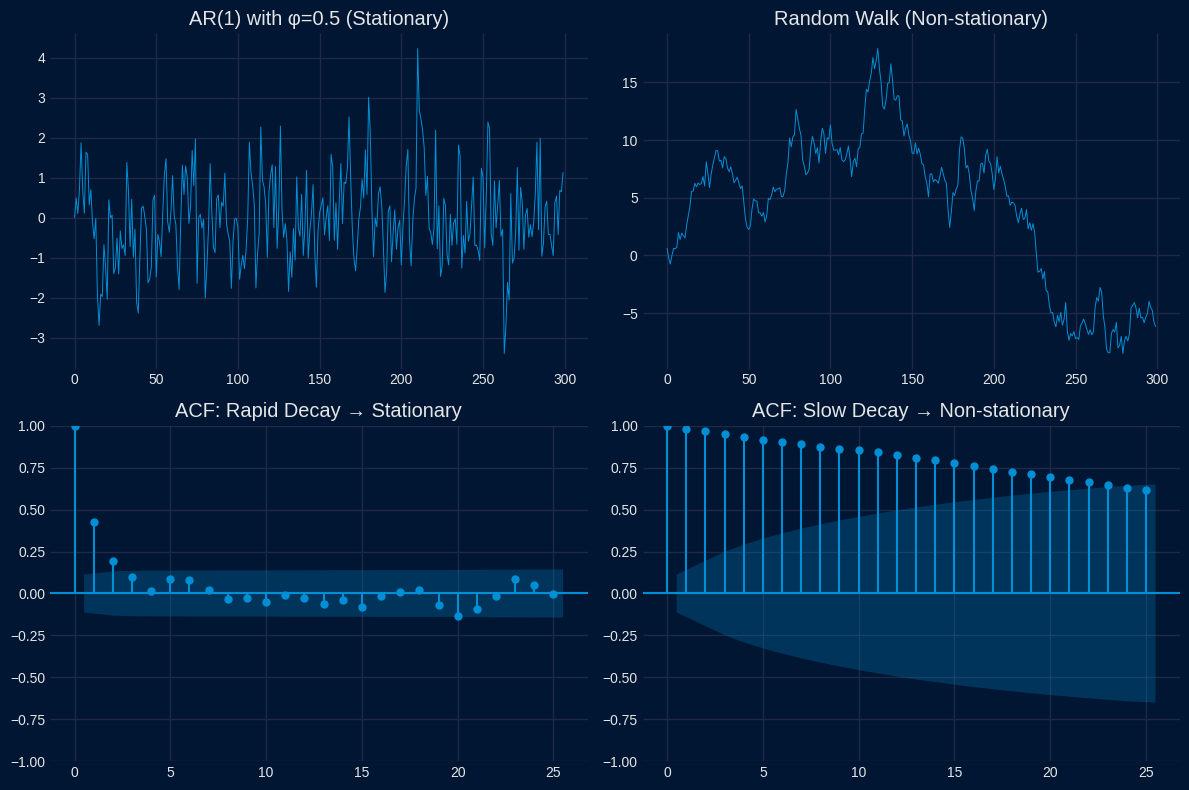

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

np.random.seed(42)
n = 300

# Stationary: AR(1) with phi = 0.5
ar1 = np.zeros(n)
for t in range(1, n):
    ar1[t] = 0.5 * ar1[t-1] + np.random.normal(0, 1)

# Non-stationary: Random walk
random_walk = np.cumsum(np.random.normal(0, 1, n))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Time series plots
axes[0, 0].plot(ar1, linewidth=0.7)
axes[0, 0].set_title('AR(1) with φ=0.5 (Stationary)')
axes[0, 1].plot(random_walk, linewidth=0.7)
axes[0, 1].set_title('Random Walk (Non-stationary)')

# ACF plots
plot_acf(ar1, lags=25, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF: Rapid Decay → Stationary')
plot_acf(random_walk, lags=25, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF: Slow Decay → Non-stationary')

plt.tight_layout()
plt.show()

### 4.5.4. Limitations of Visual Assessment

The ACF is a valuable exploratory tool, but it has an important limitation: it cannot reliably distinguish between a highly persistent stationary process (e.g., AR(1) with $\phi$ close to 1) and a true unit root ($\phi = 1$). Both produce slowly decaying ACFs that look remarkably similar.

This ambiguity motivates the need for formal statistical tests, which we introduce in the next section. We will revisit ACF and PACF plots in greater detail when studying ARIMA models, where they serve a different purpose: identifying the appropriate model order.

### 4.6. Statistical Tests for Stationarity

While visual inspection and ACF plots provide useful heuristics, we need formal statistical tests to make objective decisions about stationarity. The two most commonly used tests are the **Augmented Dickey-Fuller (ADF)** test and the **Kwiatkowski-Phillips-Schmidt-Shin (KPSS)** test.

These tests approach the problem from opposite directions, which makes using both together a powerful strategy.

#### 4.6.1. Augmented Dickey-Fuller (ADF) Test

The ADF test is designed to detect the presence of a unit root. It builds on the simpler Dickey-Fuller test but accounts for higher-order serial correlation in the data.

**The Testing Framework**

Consider the AR(1) model: $Y_t = \phi Y_{t-1} + e_t$

Subtracting $Y_{t-1}$ from both sides: $$\Delta Y_t = Y_t - Y_{t-1} = (\phi - 1) Y_{t-1} + e_t = \delta Y_{t-1} + e_t$$

where $\delta = \phi - 1$.

**Hypotheses**:

-   $H_0$: $\delta = 0$ (equivalently, $\phi = 1$) — the series has a unit root (non-stationary)
-   $H_1$: $\delta < 0$ (equivalently, $|\phi| < 1$) — the series is stationary

If we reject $H_0$, we conclude the series is stationary.

**Why "Augmented"?**

The original Dickey-Fuller test assumes the errors $e_t$ are white noise. In practice, the errors may exhibit serial correlation. The ADF test addresses this by including lagged differences:

$$\Delta Y_t = \alpha + \beta t + \delta Y_{t-1} + \sum_{j=1}^{p} \gamma_j \Delta Y_{t-j} + e_t$$

where: $\alpha$ is a constant (intercept), $\beta t$ is a deterministic trend term (optional), and $\sum_{j=1}^{p} \gamma_j \Delta Y_{t-j}$ are lagged differences to absorb serial correlation. $p$ is chosen to ensure $e_t$ is white noise.

**Test Statistic and Critical Values**

The test statistic is the t-ratio for $\delta$: $$\tau = \frac{\hat{\delta}}{SE(\hat{\delta})}$$

Under the null hypothesis of a unit root, this statistic does NOT follow a standard t-distribution. Instead, it follows a non-standard Dickey-Fuller distribution, which has different critical values (more negative than the standard t).

**Interpretation**:

-   If test statistic \< critical value: Reject $H_0$ → Series is stationary
-   If test statistic \> critical value: Fail to reject $H_0$ → Series has unit root (non-stationary)
-   Equivalently: If p-value \< 0.05: Reject $H_0$ → Series is stationary

**ADF Test in Python**

The `adfuller` function from `statsmodels` can automatically determine the optimal number of lags $p$ to include in the test regression. By default (`autolag='AIC'`), the function fits models for $p = 0, 1, \ldots, p_{\max}$ and selects the value that minimizes the Akaike Information Criterion (AIC). Alternative criteria such as BIC (`autolag='BIC'`) or sequential t-statistic testing (`autolag='t-stat'`) are also available. The maximum number of lags $p_{max}$ can be specified via the `maxlag` parameter; if left as None, a default value of $\lfloor 12 \cdot (n/100)\^{1/4} \rfloor$ is used, where $n$ is the sample size. This automatic selection helps ensure that the residuals of the test regression are free of serial correlation, which is essential for the validity of the test.

In [69]:
from statsmodels.tsa.stattools import adfuller

# Obtain example series
np.random.seed(42)
# white noise
stationary = np.random.normal(0, 1, 500)
# random walk
random_walk = np.cumsum(np.random.normal(0, 1, 500))


result_stationary = adfuller(stationary) #default: maxlag='None', autolag='AIC'
print(f"\n{'='*65}")
print(f"Augmented Dickey-Fuller Test: white noise (should be stationary)")
print('='*65)
print(f"P-value:                {result_stationary[1]:.4f}")
print(f"Lags Used:              {result_stationary[2]}")
print(f"Number of Observations: {result_stationary[3]}")
    
result_rw = adfuller(random_walk) #default: maxlag='None', autolag='AIC'
print(f"\n{'='*65}")
print(f"Augmented Dickey-Fuller Test: random walk (should be non-stationary - unit root)")
print('='*65)
print(f"P-value:                {result_rw[1]:.4f}")
print(f"Lags Used:              {result_rw[2]}")
print(f"Number of Observations: {result_rw[3]}")


Augmented Dickey-Fuller Test: white noise (should be stationary)
P-value:                0.0000
Lags Used:              0
Number of Observations: 499

Augmented Dickey-Fuller Test: random walk (should be non-stationary - unit root)
P-value:                0.9280
Lags Used:              0
Number of Observations: 499


#### 4.6.2. KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin)

The KPSS test takes the opposite approach to the ADF test: it tests the null hypothesis of stationarity.

**Hypotheses**:

-   $H_0$: The series is stationary (around a deterministic trend)
-   $H_1$: The series has a unit root (non-stationary)

**The Model**

The KPSS test decomposes the series as: $$Y_t = \xi t + r_t + \epsilon_t$$

where $\xi t$ is a deterministic trend, $r_t = r_{t-1} + u_t$ is a random walk, and $\epsilon_t$ is a stationary error

Under $H_0$ (stationarity), the variance of $u_t$ is zero, meaning $r_t$ is constant and the series is stationary around a trend.

**Test Statistic**

The KPSS test statistic is based on the cumulative sum of residuals: $$\text{KPSS} = \frac{\sum_{t=1}^{T} S_t^2}{T^2 \hat{\sigma}^2}$$

where $S_t = \sum_{i=1}^{t} \hat{e}_i$ is the cumulative sum of residuals.

**Interpretation**:

-   If test statistic \> critical value: Reject $H_0$ → Series is non-stationary
-   If test statistic \< critical value: Fail to reject $H_0$ → Series is stationary
-   Equivalently: If p-value \< 0.05, the series is non-stationary

**Note**: The logic is reversed compared to ADF. Small p-values in KPSS indicate non-stationarity.

**KPSS Test in Python**

The `kpss` function from `statsmodels` allows for the specification of the deterministic component via the `regression` parameter. Setting `regression='c'` tests for stationarity around a constant level (implying $\xi=0$ in the model), whereas `regression='ct'` tests for stationarity around a deterministic trend. Regarding the test statistic denominator, the `nlags` parameter controls the lag truncation used to estimate the long-run variance $\hat{\sigma}^2$. When set to `nlags='auto'`, the function automatically determines the optimal number of lags based on the sample size (typically using a data-dependent rule). This automatic bandwidth selection is crucial for computing a Heteroskedasticity and Autocorrelation Consistent (HAC) estimator, ensuring the test statistic remains robust to short-term serial correlation under the null hypothesis.

In [70]:
from statsmodels.tsa.stattools import kpss

# regression: 'c' for constant (level stationarity)
#             'ct' for constant + trend (trend stationarity)
result_stationary = kpss(stationary, regression='c', nlags='auto')
print(f"\n{'='*65}")
print(f"KPSS Test: White Noise (should be stationary)")
print('='*65)
print(f"P-value:                {result_stationary[1]:.4f}")
print(f"Lags Used:              {result_stationary[2]}")

result_rw = kpss(random_walk, regression='c', nlags='auto')
print(f"\n{'='*65}")
print(f"KPSS Test: Random Walk (should be non-stationary)")
print('='*65)
print(f"P-value:                {result_rw[1]:.4f}")
print(f"Lags Used:              {result_rw[2]}")


KPSS Test: White Noise (should be stationary)
P-value:                0.1000
Lags Used:              1

KPSS Test: Random Walk (should be non-stationary)
P-value:                0.0100
Lags Used:              12


#### 4.6.3. Using ADF and KPSS Together: A Confirmatory Strategy

Since ADF and KPSS have opposite null hypotheses, using both tests provides stronger evidence:

| ADF Result | KPSS Result | Conclusion |
|:-----------------------|:-----------------------|:-----------------------|
| Reject $H_0$ (p \< 0.05) | Fail to reject $H_0$ (p ≥ 0.05) | **Strong evidence of stationarity** |
| Fail to reject $H_0$ (p ≥ 0.05) | Reject $H_0$ (p \< 0.05) | **Strong evidence of non-stationarity** |
| Reject $H_0$ | Reject $H_0$ | Conflicting—possibly trend-stationary |
| Fail to reject $H_0$ | Fail to reject $H_0$ | Conflicting—low power / borderline case |

Recommended workflow:

1.  Always run both tests
2.  Look for consistent results
3.  If results conflict, examine the data visually and consider transformation

#### 4.6.4. Important Caveats and Limitations

Statistical tests for stationarity are not perfect. Be aware of these limitations:

**Low Power with Small Samples**: Both ADF and KPSS tests have reduced ability to detect the true state with small sample sizes. False positives (ADF) and false negatives (KPSS) become more common.

**Near Unit Roots**: When $\phi$ is close to 1 (e.g., $\phi = 0.95$), it becomes very difficult for tests to distinguish between a stationary process with high persistence and a true unit root.

**Structural Breaks**: If the data contains structural breaks (sudden changes in mean or variance), tests may give misleading results.

**Multiple Unit Roots**: The tests are designed for single unit roots. Seasonal unit roots require specialized tests.

**Variance Non-Stationarity**: ADF and KPSS primarily test for mean stationarity. They do not directly test whether variance is changing over time. Variance issues are typically addressed through transformations (log, Box-Cox) rather than formal testing.

> **Critical Thinking**: Why might a series pass both stationarity tests but still be inappropriate for a model that assumes stationarity? Consider what aspects of "stationarity" these tests actually measure versus what the model might need.

------------------------------------------------------------------------

### 4.7. Exercises

**Exercise 4.1**: For each of the following, determine whether the process is stationary. If not, identify which condition of weak stationarity is violated.

a)  $Y_t = 5 + 0.8Y_{t-1} + e_t$ where $e_t \sim N(0, 1)$

b)  $Y_t = t + e_t$ where $e_t \sim N(0, 1)$

c)  $Y_t = Y_{t-1} + e_t$ where $e_t \sim N(0, t)$

d)  $Y_t = (-1)^t \cdot e_t$ where $e_t \sim N(0, 1)$

**Exercise 4.2**: Load the Australian quarterly beer production data (used in Section 5). Apply the complete stationarity workflow:

1.  Plot the series and visually assess stationarity
2.  Perform ADF and KPSS tests on the original series
3.  If non-stationary, apply appropriate transformations
4.  Verify stationarity of the transformed series

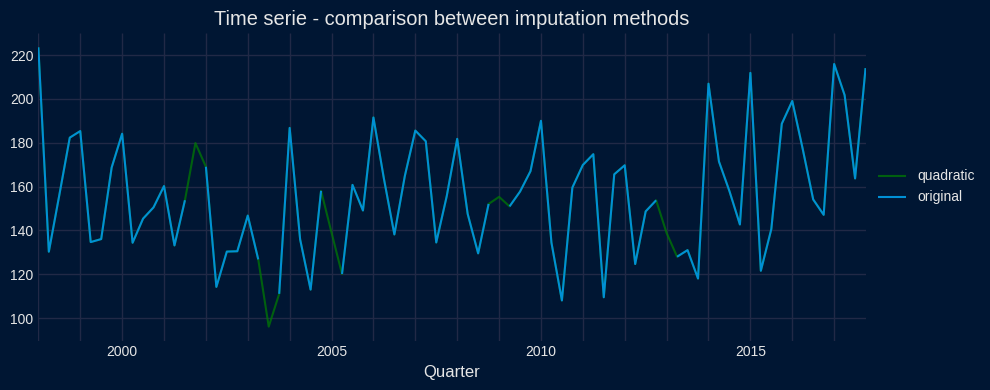

In [71]:
tourism = pd.read_excel("./Data/tourism.xlsx", engine="openpyxl")
tourism['Quarter'] = pd.to_datetime(tourism['Quarter'],format='%Y-%m-%d')
tourism = tourism[(tourism['Region']=='Adelaide') & (tourism['Purpose']=='Holiday')]
tourism = tourism.set_index('Quarter')
tourism = tourism.asfreq('QS')
tourism_imputed_quad = tourism.copy()
tourism_imputed_quad['Trips'] = tourism['Trips'].interpolate(method="quadratic")
fig, ax = plt.subplots(figsize=(10, 4))
tourism_imputed_quad['Trips'].plot(ax=ax, label='quadratic', color="green", alpha=0.7)
tourism['Trips'].plot(ax=ax, label='original')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie - comparison between imputation methods")
plt.tight_layout() 
plt.show()

In [76]:
result_stationary = adfuller(tourism_imputed_quad['Trips']) #default: maxlag='None', autolag='AIC'
print(f"\n{'='*65}")
print(f"Augmented Dickey-Fuller Test: tourism_imputed_quad")
print('='*65)
print(f"P-value:                {result_stationary[1]:.4f}")
print(f"Lags Used:              {result_stationary[2]}")
print(f"Number of Observations: {result_stationary[3]}")

result_stationary = kpss(tourism_imputed_quad['Trips'], regression='c', nlags='auto')
print(f"\n{'='*65}")
print(f"KPSS Test: tourism_imputed_quad")
print('='*65)
print(f"P-value:                {result_stationary[1]:.4f}")
print(f"Lags Used:              {result_stationary[2]}")


Augmented Dickey-Fuller Test: tourism_imputed_quad
P-value:                0.6759
Lags Used:              9
Number of Observations: 70

KPSS Test: tourism_imputed_quad
P-value:                0.0639
Lags Used:              2


| ADF Result | KPSS Result | Conclusion |
|:-----------------------|:-----------------------|:-----------------------|
| Reject $H_0$ (p \< 0.05) | Fail to reject $H_0$ (p ≥ 0.05) | **Strong evidence of stationarity** |
| Fail to reject $H_0$ (p ≥ 0.05) | Reject $H_0$ (p \< 0.05) | **Strong evidence of non-stationarity** |
| Reject $H_0$ | Reject $H_0$ | Conflicting—possibly trend-stationary |
| Fail to reject $H_0$ | Fail to reject $H_0$ | Conflicting—low power / borderline case |

In [89]:
differences_t1 = []
for i in range(len(tourism_imputed_quad['Trips']) - 1):
    differences_t1.append(tourism_imputed_quad['Trips'].iloc[i+1] - tourism_imputed_quad['Trips'].iloc[i])

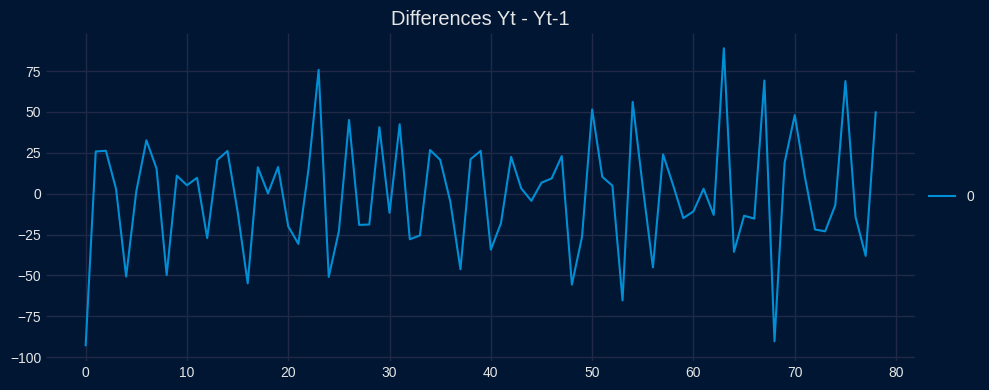

In [90]:
fig, ax = plt.subplots(figsize=(10, 4))
pd.DataFrame(differences_t1).plot(ax=ax, label='original')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Differences Yt - Yt-1")
plt.tight_layout() 
plt.show()

In [91]:
result_stationary = adfuller(differences_t1) #default: maxlag='None', autolag='AIC'
print(f"\n{'='*65}")
print(f"Augmented Dickey-Fuller Test: differences_t1")
print('='*65)
print(f"P-value:                {result_stationary[1]:.4f}")
print(f"Lags Used:              {result_stationary[2]}")
print(f"Number of Observations: {result_stationary[3]}")

result_stationary = kpss(differences_t1, regression='c', nlags='auto')
print(f"\n{'='*65}")
print(f"KPSS Test: differences_t1")
print('='*65)
print(f"P-value:                {result_stationary[1]:.4f}")
print(f"Lags Used:              {result_stationary[2]}")


Augmented Dickey-Fuller Test: differences_t1
P-value:                0.3268
Lags Used:              12
Number of Observations: 66

KPSS Test: differences_t1
P-value:                0.0911
Lags Used:              16


| ADF Result | KPSS Result | Conclusion |
|:-----------------------|:-----------------------|:-----------------------|
| Reject $H_0$ (p \< 0.05) | Fail to reject $H_0$ (p ≥ 0.05) | **Strong evidence of stationarity** |
| Fail to reject $H_0$ (p ≥ 0.05) | Reject $H_0$ (p \< 0.05) | **Strong evidence of non-stationarity** |
| Reject $H_0$ | Reject $H_0$ | Conflicting—possibly trend-stationary |
| Fail to reject $H_0$ | Fail to reject $H_0$ | Conflicting—low power / borderline case |

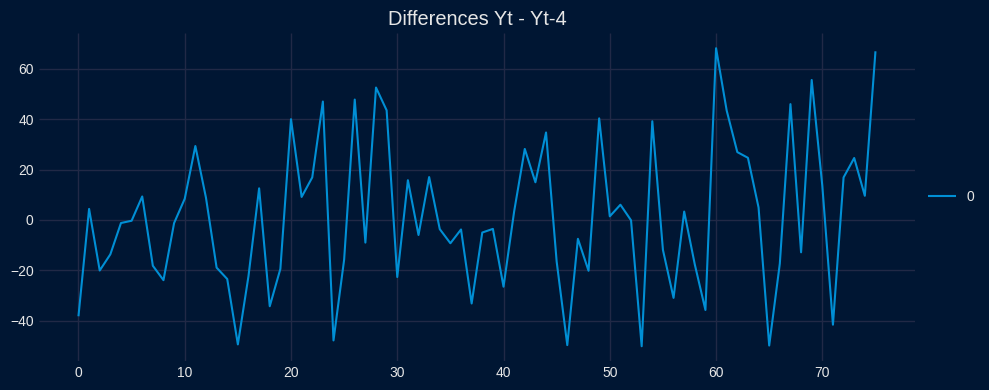

In [96]:
differences_t4 = []
for i in range(len(tourism_imputed_quad['Trips']) - 4):
    differences_t4.append(tourism_imputed_quad['Trips'].iloc[i+4] - tourism_imputed_quad['Trips'].iloc[i])
fig, ax = plt.subplots(figsize=(10, 4))
pd.DataFrame(differences_t4).plot(ax=ax, label='original')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Differences Yt - Yt-4")
plt.tight_layout() 
plt.show()

In [97]:
result_stationary = adfuller(differences_t4) #default: maxlag='None', autolag='AIC'
print(f"\n{'='*65}")
print(f"Augmented Dickey-Fuller Test: differences_t4")
print('='*65)
print(f"P-value:                {result_stationary[1]:.4f}")
print(f"Lags Used:              {result_stationary[2]}")
print(f"Number of Observations: {result_stationary[3]}")

result_stationary = kpss(differences_t4, regression='c', nlags='auto')
print(f"\n{'='*65}")
print(f"KPSS Test: differences_t1")
print('='*65)
print(f"P-value:                {result_stationary[1]:.4f}")
print(f"Lags Used:              {result_stationary[2]}")


Augmented Dickey-Fuller Test: differences_t4
P-value:                0.2964
Lags Used:              11
Number of Observations: 64

KPSS Test: differences_t1
P-value:                0.1000
Lags Used:              1


**Exercise 4.3**: Consider a time series that passes the ADF test (appears stationary) but fails the KPSS test (appears non-stationary). What might be happening? Provide a concrete example and suggest how to resolve this ambiguity.

------------------------------------------------------------------------

## 5. Time Series Decomposition

One of the main objectives for a decomposition is to estimate seasonal effects that can be used to create and present seasonally adjusted values.

A seasonally adjusted value removes the seasonal effect from a value so that trends can be seen more clearly.

Example: in Spain, unemployment tends to decrease in the summer due to increased employment in major touristic areas. Thus, a drop in the unemployment rate in July compared to June doesn’t necessarily indicate that there’s a trend toward lower unemployment in the country. To see whether there is a real trend, we should adjust for the fact that unemployment is always lower in July than in June.

How these components interact defines the mathematical model. Choosing the correct structure is crucial for forecast accuracy.

### 5.1. Basic structures

#### 5.1.1. Additive Model

$Y_t = Trend + Seasonal + Random \text{ (irregular component) } = T_t + S_t + C_t + \epsilon_t$

Used when the magnitude of fluctuations (variation around the trend-cycle) is relatively constant over time. That is, the amplitude of the seasonal spikes is roughly the same, regardless of whether the trend is high or low.

*Example:* Daily temperature variations (summer is roughly $X$ degrees hotter than winter, regardless of long-term climate change).

#### 5.1.2. Multiplicative Model

$Y_t = \text{Trend} \times \text{Seasonal} \times \text{Random (irregular component)} = T_t\times S_t\times C_t \times \epsilon_t$

Used when the magnitude of fluctuations changes proportionally to the trend. That is, the variation in the seasonal pattern, or the variation around the trend-cycle, increases over time

*Example*: Multiplicative decompositions are common with economic time series. Over a period of 40 years, the total amount of money spent on retail sales in a country.

![Aditive vs. multiplicative models](Figures/aditive-vs-multiplicative.png)

### 5.2 Classical Decomposition Method

-   The classical method of time series decomposition originated in the 1920s and was widely used until the 1950s.

-   It still forms the basis of many time series decomposition methods, so it is important to understand how it works.

-   The first step in a classical decomposition is to use a moving average method to estimate the trend-cycle, so we begin by discussing moving averages.

#### 5.2.1. Moving average smoothing

A moving average of order m can be written as

$$
\hat{T}_t=\frac{1}{m}\sum_{j=-k}^k y_{t+j},
$$

where$m=2k+1$.

-   That is, the estimate of the trend-cycle at time $t$ is obtained by averaging values of the time series within $k$ periods of $t$.

-   Observations that are nearby in time are also likely to be close in value. Therefore, the average eliminates some of the randomness in the data, leaving a smooth trend-cycle component.

-   We call this an $m$-MA, meaning a moving average of order $m$.

Example: exports of goods and services for Australia as a percentage of GDP from 1960 to 2017.

![](Figures/plot35_MA_aus-exports-1.png)

##### Moving averages (by hand)

*Annual Australian exports of goods and services: 1960–2017.*

| Year | Exports | 5-MA  |
|------|---------|-------|
| 1960 | 12.99   |       |
| 1961 | 12.40   |       |
| 1962 | 13.94   | 13.46 |
| 1963 | 13.01   | 13.50 |
| 1964 | 14.94   | 13.61 |
| 1965 | 13.22   | 13.40 |
| 1966 | 12.93   | 13.25 |
| 1967 | 12.88   | 12.66 |
| ...  | ...     |       |
| 2010 | 19.84   | 21.21 |
| 2011 | 21.47   | 21.17 |
| 2012 | 21.52   | 20.78 |
| 2013 | 19.99   | 20.81 |
| 2014 | 21.08   | 20.37 |
| 2015 | 20.01   | 20.32 |
| 2016 | 19.25   |       |
| 2017 | 21.27   |       |

-   In the last column of this table, a moving average of order 5 is shown, providing an estimate of the trend-cycle.

-   The first value in this column is the average of the first five observations, 1960–1964; the second value in the 5-MA column is the average of the values for 1961–1965; and so on.

-   Each value in the 5-MA column is the average of the observations in the five year window centered on the corresponding year. Column 5-MA contains the values of $\hat{T}$ with $k=2$ and $m=2k+1=5$.

-   There are no values for either the first two years or the last two years, because we do not have two observations on either side.

-   We will use more sophisticated methods of trend-cycle estimation which do allow estimates near the endpoints.

##### Original data with the trend-cycle estimate

To see what the trend-cycle estimate looks like, we plot it (in orange) along with the original data

![](Figures/plot36-_MA_exports-2.png)

-   Notice that the trend-cycle (in orange) is smoother than the original data and captures the main movement of the time series without all of the minor fluctuations.

-   The order of the moving average determines the smoothness of the trend-cycle estimate.

-   In general, a larger order means a smoother curve.

-   Simple moving averages such as these are usually of an odd order (e.g., 3, 5, 7, etc.).

-   This is so as they are symmetric: in a moving average of order $m=2k+1$, the middle observation, and $k$ observations on either side, are averaged. But if $m$ was even, it would no longer be symmetric.

##### Exercise

Run first the following code in Python. Compute MA of order 3, 7, and 9. Interpret results

     Year    Exports
638  1960  12.994452
639  1961  12.403101
640  1962  13.943012
641  1963  13.005886
642  1964  14.938248
643  1965  13.220178
644  1966  12.932380
645  1967  12.883730
646  1968  12.297668
647  1969  11.954860
648  1970  12.977037
649  1971  12.661274
650  1972  12.825759
651  1973  14.155022
652  1974  13.151999
653  1975  14.281497
654  1976  13.523127
655  1977  14.022905
656  1978  13.628173
657  1979  14.311982
658  1980  16.439467
659  1981  14.912067
660  1982  13.541038
661  1983  13.594733
662  1984  13.580218
663  1985  15.259988
664  1986  15.013742
665  1987  15.494314
666  1988  15.984146
667  1989  15.145868
668  1990  15.143563
669  1991  16.059044
670  1992  16.691404
671  1993  17.573663
672  1994  18.005892
673  1995  17.916885
674  1996  18.939194
675  1997  19.174811
676  1998  19.595577
677  1999  18.353956
678  2000  19.443482
679  2001  22.235182
680  2002  20.783136
681  2003  19.103004
682  2004  17.219765
683  2005  18.285302
684  2006  19

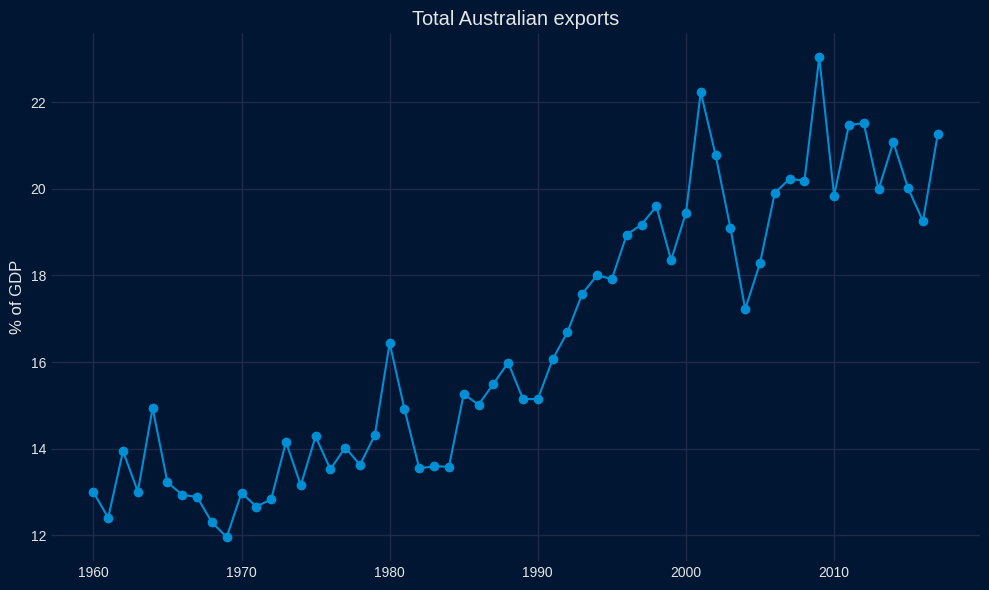

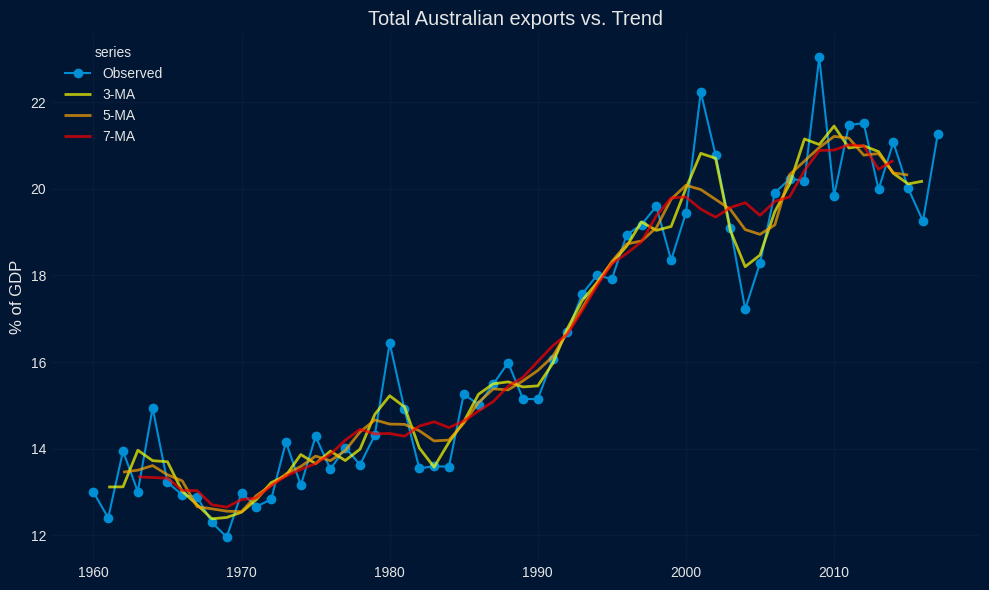

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos desde el archivo Excel
global_economy = pd.read_excel('./Data/global_economy.xlsx')

# To select and view Exports Data
data = global_economy[global_economy['Country'] == 'Australia'][['Year', 'Exports']]
print(data)

# To represent the time series of Export data
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data['Year'], data['Exports'], marker='o')
ax.set_ylabel('% of GDP')
ax.set_title('Total Australian exports')
#plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# To compute 3-MA
aus_exports_3MA = data.copy()
aus_exports_3MA['3-MA'] = aus_exports_3MA['Exports'].rolling(
    window=3, 
    center=True, 
    min_periods=3
).mean()

# To compute 5-MA
aus_exports = data.copy()
aus_exports['5-MA'] = aus_exports['Exports'].rolling(
    window=5, 
    center=True, 
    min_periods=5
).mean()

# To compute 7-MA
aus_exports_7MA = data.copy()
aus_exports_7MA['7-MA'] = aus_exports_7MA['Exports'].rolling(
    window=7, 
    center=True, 
    min_periods=7
).mean()


# To see what the trend-cycle estimate looks like, we plot it along with the original data
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data['Year'], data['Exports'], marker='o', label="Observed")
ax.set_ylabel('% of GDP')
ax.set_title('Total Australian exports vs. Trend')
ax.plot(aus_exports_3MA['Year'], aus_exports_3MA['3-MA'], 
         color='yellow', linewidth=2, label='3-MA', alpha=0.7)
ax.plot(aus_exports['Year'], aus_exports['5-MA'], 
         color='orange', linewidth=2, label='5-MA', alpha=0.7)
ax.plot(aus_exports_7MA['Year'], aus_exports_7MA['7-MA'], 
         color='red', linewidth=2, label='7-MA', alpha=0.7)
plt.legend(title='series')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 5.2.2. Moving averages of moving averages

-   It is possible to apply a moving average to a moving average. One reason for doing this is to make an even-order moving average symmetric**.**

-   For example, we might take a moving average of order 4, and then apply another moving average of order 2 to the results.

##### Example - Australian quarterly beer production data

A moving average of order 4 applied to the quarterly beer data, followed by a moving average of order 2.

| Quarter | Beer   | 4-MA   | 2x4-MA |
|---------|--------|--------|--------|
| 1992 Q1 | 443.00 |        |        |
| 1992 Q2 | 410.00 | 451.25 |        |
| 1992 Q3 | 420.00 | 448.75 | 450.00 |
| 1992 Q4 | 532.00 | 451.50 | 450.12 |
| 1993 Q1 | 433.00 | 449.00 | 450.25 |
| 1993 Q2 | 421.00 | 444.00 | 446.50 |
| ...     | ...    | ...    | ...    |
| 2009 Q1 | 415.00 | 430.00 | 428.88 |
| 2009 Q2 | 398.00 | 430.00 | 430.00 |
| 2009 Q3 | 419.00 | 429.75 | 429.88 |
| 2009 Q4 | 488.00 | 423.75 | 426.75 |
| 2010 Q1 | 414.00 |        |        |
| 2010 Q2 | 374.00 |        |        |

-   "2×4-MA" in the last column means a 4-MA followed by a 2-MA.

-   The values in the last column are obtained by taking a moving average of order 2 of the values in the previous column.

-   For example, the first two values in the 4-MA column are $451.25=(443+410+420+532)/4$ and $448.75=(410+420+532+433)/4$.

-   The first value in the 2x4-MA column is the average of these two: $450.00=(451.25+448.75)/2$.

When a 2-MA follows a moving average of an even order (such as 4), it is called a "centred moving average of order 4." This is because the results are now symmetric

-   To see that this is the case, we can write the 2×4-MA as follows:

$$
\begin{aligned}
\hat{T}_{t} =& \frac{1}{2}\left[\frac{1}{4}\left(y_{t-2}+y_{t-1}+y_{t}+y_{t+1}\right)+\frac{1}{4}\left(y_{t-1}+y_{t}+y_{t+1}+y_{t+2}\right)\right] \\
=& \frac{1}{8} y_{t-2}+\frac{1}{4} y_{t-1}+\frac{1}{4} y_{t}+\frac{1}{4} y_{t+1}+\frac{1}{8} y_{t+2}
\end{aligned}
$$

-   It is now a weighted average of observations that is symmetric
-   Other combinations of moving averages are also possible.
-   For example, a 3x3-MA is often used, and consists of a moving average of order 3 followed by another moving average of order 3.
-   In general, an even order MA should be followed by an even order MA to make it symmetric.
-   Similarly, an odd order MA should be followed by an odd order MA.

##### Computing moving averages of moving averages in Python

In [100]:
import pandas as pd

# load Australian beer production dataset
beer = pd.read_excel("./Data/beerProduction_aus.xlsx")

print(beer.head())
beer['Date'] = pd.to_datetime(beer['Date'],format='%Y-%m-%d')
beer = beer.set_index(['Date'])
beer = beer.asfreq('QS')
beer = beer.loc['1992':]

beer['4-MA'] = beer['Beer'].rolling(window=4, center=True).mean()
beer['2x4-MA'] = beer['4-MA'].rolling(window=2, center=True).mean().shift(-1)

print("\nResults with Moving Average:")
print(beer.head())
print(beer.tail())

        Date  Beer
0 1956-01-01   284
1 1956-04-01   213
2 1956-07-01   227
3 1956-10-01   308
4 1957-01-01   262

Results with Moving Average:
            Beer    4-MA   2x4-MA
Date                             
1992-01-01   443     NaN      NaN
1992-04-01   410     NaN      NaN
1992-07-01   420  451.25  450.000
1992-10-01   532  448.75  450.125
1993-01-01   433  451.50  450.250
            Beer    4-MA   2x4-MA
Date                             
2009-04-01   398  430.00  430.000
2009-07-01   419  430.00  429.875
2009-10-01   488  429.75  426.750
2010-01-01   414  423.75      NaN
2010-04-01   374     NaN      NaN


#### 5.2.3. Estimating the trend-cycle with seasonal data

The most common use of centred moving averages is for estimating the trend-cycle from seasonal data. Consider the 2x4-MA:

$$
\hat{T}_{t} =\frac{1}{8} y_{t-2}+\frac{1}{4} y_{t-1}+\frac{1}{4} y_{t}+\frac{1}{4} y_{t+1}+\frac{1}{8}y_{t+2}
$$

-   When applied to quarterly data, each quarter of the year is given equal weight as the first and last terms apply to the same quarter in consecutive years, e.g. if $t= Q3$:

    | Term      | Correspons to | Weight |
    |-----------|---------------|--------|
    | $y_{t-2}​$ | Q1 2024       | 1/8    |
    | $y_{t-1}$​ | Q2 2024       | 1/4    |
    | $y_t$     | Q3 2024       | 1/4    |
    | $y_{t+1}$​ | Q4 2024       | 1/4    |
    | $y_{t+2}$​ | Q1 2025       | 1/8    |

-   Consequently, the seasonal variation will be averaged out and the resulting values of $\hat{T}$ will have little or no seasonal variation remaining

-   A similar effect would be obtained using a 2x8-MA or a 2x12-MA to quarterly data.

##### Example: Employment in the US retail sector

Total monthly number of persons in thousands employed in the retail sector across the US since 1990. As data present monthly frequency we use a **2x12-MA**. Any other choice for the order of the moving average (except for 24, 36, etc.) would have resulted in a smooth line that showed some seasonal fluctuations.

In [ ]:
import pandas as pd

# load US retail employment dataset
employment = pd.read_excel("./Data/us_retail_employment.xlsx")

employment.head()
employment['Date'] = pd.to_datetime(employment['Date'],format='%Y-%m-%d')
employment = employment.set_index(['Date'])
employment = employment.asfreq('MS')


employment['12-MA'] = employment['Employed'].rolling(window=12, center=True).mean()
employment['2x12-MA'] = employment['12-MA'].rolling(window=2, center=True).mean().shift(-1)

print("\nResults with Moving Average:")
fig, ax = plt.subplots()
employment['Employed'].plot(ax=ax, label="Original Data")
employment['2x12-MA'].plot(ax=ax, label="Trend-Cycle (2x12MA)")
plt.title(' US retail employment - monthly data')
plt.tight_layout()
plt.show()

#### 5.2.4. Weighted moving averages

-   Combinations of moving averages result in weighted moving averages.

-   For example, the 2x4-MA discussed above is equivalent to a weighted 5-MA with weights given by $[1/8,1/4,1/4,1/4,1/8]$

-   In general, a weighted m-MA can be written as

$$
\hat{T}_t=\sum_{j=-k}^{k}a_jy_{t+j},
$$

where $k=(m-1)/2$, and the weights are given by $[a_{-k},\ldots, a_k]$

-   It is important that the weights all sum to one and that they are symmetric so that $a_j=a_{-j}$

-   The simple m-MA is a special case where all of the weights are equal to $1/m$.

-   A major advantage of weighted moving averages is that they yield a smoother estimate of the trend-cycle. Instead of observations entering and leaving the calculation at full weight, their weights slowly increase and then slowly decrease, resulting in a smoother curve.

#### 5.2.5. Basic Steps in the Classical Decomposition {#basic-steps-in-the-classical-decomposition}

1.  **The first step is to estimate the trend.** If m is an even number, compute the trend-cycle component $\hat{T}_t$ using a 2xm-MA. If m is an odd number, compute the trend-cycle component using an m-MA.

2.  **The second step is to "de-trend" the series.** For an additive decomposition, this is done by subtracting the trend estimates from the series. For a multiplicative decomposition, this is done by dividing the series by the trend values.

3.  **Next, seasonal factors are estimated using the de-trended series.** For monthly data, this entails estimating an effect for each month of the year. For quarterly data, this entails estimating an effect for each quarter. The simplest method for estimating these effects is to average the de-trended values for a specific season. For instance, to get a seasonal effect for January, we average the de-trended values for all Januarys in the series, and so on. These seasonal component values are then adjusted to ensure that they add to zero in an additive decomposition and add to $m$ in a multiplicative decomposition. This gives $\hat{S}_t$.

4.  **The final step is to determine the random (irregular) component.**

    -   For the additive model, random = series – trend – seasonal.
    -   For the multiplicative model, random = series / (trend×seasonal)

##### Example using Python. Additive decomposition of Beer Production Data

The basic command is `seasonal_decompose` from the `statsmodels.tsa.seasonal` package.

-   For an additive model decomposition

    `seasonal_decompose(data, model='additive', period=m)`

-   For a multiplicative decomposition

    `seasonal_decompose(data, model='multiplicative', period=m)`

$m$ defines the seasonal span for a series: quaterly data ($m=4$), monthly data ($m=12$), ...

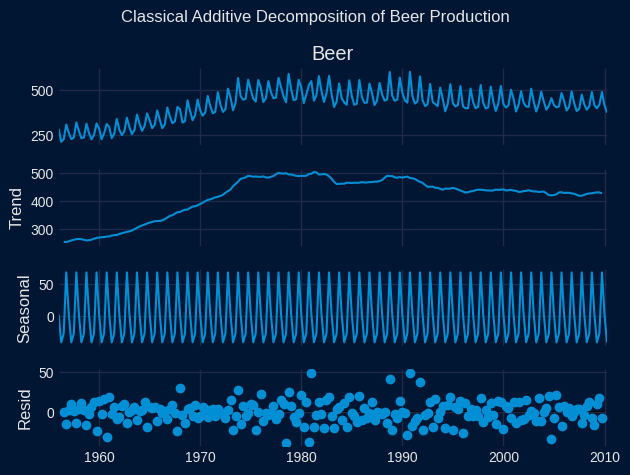

--- Numerical Results (Head) ---
Trend:
 Date
1956-01-01        NaN
1956-04-01        NaN
1956-07-01    255.250
1956-10-01    254.375
1957-01-01    257.375
Freq: QS-JAN, Name: trend, dtype: float64
Seasonal:
 Date
1956-01-01     2.131016
1956-04-01   -42.519927
1956-07-01   -28.505776
1956-10-01    68.894687
1957-01-01     2.131016
Freq: QS-JAN, Name: seasonal, dtype: float64
Residuals:
 Date
1956-01-01          NaN
1956-04-01          NaN
1956-07-01     0.255776
1956-10-01   -15.269687
1957-01-01     2.493984
Freq: QS-JAN, Name: resid, dtype: float64


In [103]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ---------------------------------------------------------
# 1. Data Loading and Preprocessing
# ---------------------------------------------------------
beer = pd.read_excel("./Data/beerProduction_aus.xlsx")
beer['Date'] = pd.to_datetime(beer['Date'],format='%Y-%m-%d')
beer = beer.set_index(['Date'])
beer = beer.asfreq('QS')

# ---------------------------------------------------------
# 2. Classical Decomposition
# ---------------------------------------------------------
# Apply seasonal decomposition using moving averages.
# Parameters:
#   - model='additive'
#   - period=4: Defines the seasonal span (Quarterly data)
result = seasonal_decompose(beer['Beer'], model='additive', period=4)

# ---------------------------------------------------------
# 3. Visualization and Results
# ---------------------------------------------------------
# Plot the four components: Observed, Trend, Seasonal, and Residual.
result.plot()
plt.suptitle("Classical Additive Decomposition of Beer Production")
plt.tight_layout()
plt.show()

# Accessing numerical results. We print the first few rows of each component.
print("--- Numerical Results (Head) ---")
print("Trend:\n", result.trend.head())
print("Seasonal:\n", result.seasonal.head())
print("Residuals:\n", result.resid.head())

-   The seasonal pattern is a regularly repeating pattern (each year).

-   The seasonal values are used to seasonally adjust future values.

-   Suppose for example that the next quarter 4 value past the end of the series is 535. The quarter 4 seasonal effect is approximately 68.89. Thus for this future value, the "de-seasonalized" or seasonally adjusted value is $535 - 68.89 = 466.11$.

#### 5.2.3. Comments on classical decomposition

While classical decomposition is still widely used, it is not recommended, as there are now several much better methods. Some of the problems with classical decomposition are summarised below:

-   The estimate of the trend-cycle is unavailable for the first few and last few observations. For example, if m=12, there is no trend-cycle estimate for the first six or the last six observations. Consequently, there is also no estimate of the remainder component for the same time periods.

-   The trend-cycle estimate tends to over-smooth rapid rises and falls in the data.

-   Classical decomposition methods are unable to capture seasonal changes over time.

-   Occasionally, the values of the time series in a small number of periods may be particularly unusual. For example, the monthly air passenger traffic may be affected by an industrial dispute, making the traffic during the dispute different from usual. The classical method is not robust to these kinds of unusual values.

### 5.3. STL decomposition {#stl-decomposition}

STL is a versatile and robust method for decomposing time series. STL is an acronym for "Seasonal and Trend decomposition using Loess", while loess is a method for estimating nonlinear relationships. The STL method was developed by R. B. Cleveland et al. (1990).

STL has several **advantages** over classical decomposition:

-   STL will handle any type of seasonality, not only monthly and quarterly data.

-   The seasonal component is allowed to change over time, and the rate of change can be controlled by the user.

-   The smoothness of the trend-cycle can also be controlled by the user.

-   It can be robust to outliers (i.e., the user can specify a robust decomposition), so that occasional unusual observations will not affect the estimates of the trend-cycle and seasonal components. They will, however, affect the remainder component.

On the other hand, STL has some **disadvantages**. For example, it only provides facilities for additive decompositions.

-   A multiplicative decomposition can be obtained by first taking logs of the data, then back-transforming the components.

-   Decompositions that are between additive and multiplicative can be obtained using a Box-Cox transformation of the data with $0< \lambda <1$. A value of $\lambda=0$ gives a multiplicative decomposition while $\lambda=1$ gives an additive decomposition.

-   The R command `STL` does a good job.

-   The R command `stl` does an additive decomposition in which a lowess smoother is used to estimate the trend and (potentially) the seasonal effects as well. There are several parameters that can be adjusted, but the default does a fairly good job.

#### 5.3.1 STL decomposition of the beer data in Python

In [ ]:
from statsmodels.tsa.seasonal import STL

# ---------------------------------------------------------
# 1. STL Model Definition
# ---------------------------------------------------------
# Initialize the STL model (Seasonal-Trend decomposition using LOESS).
# This is preferred in modern analysis over classical decomposition due to its robustness.
# Parameters:
#   - period=4: Quarterly seasonality.
#   - robust=True: Reduces the influence of outliers (similar to robust features in fable).
stl = STL(beer['Beer'], period=4, robust=True)

# Fit the model to the data
res_stl = stl.fit()

# ---------------------------------------------------------
# 2. Visualization and Results
# ---------------------------------------------------------
fig = res_stl.plot()
plt.suptitle("STL Decomposition (Robust)")
plt.tight_layout()
plt.show()

# Accessing numerical results. We print the first few rows of each component.
print("--- Numerical Results (Head) ---")
print('Observed:\n', res_stl.observed.head())
print('Trend:\n', res_stl.trend.head())
print('seasonal:\n', res_stl.seasonal.head())
print('remainder:\n', res_stl.resid.head())

-   The two main parameters to be chosen when using STL are the trend-cycle window `STL(trend = ?)` and the seasonal window `STL(seasonal = ?)`

-   These control how rapidly the trend-cycle and seasonal components can change. Smaller values allow for more rapid changes.

-   Both trend and seasonal windows should be odd numbers

-   Trend window is the number of consecutive observations to be used when estimating the trend-cycle

-   Season window is the number of consecutive years to be used in estimating each value in the seasonal component

-   By default, the STL() function provides a convenient automated STL decomposition using a seasonal window of ``` STL(``seasonal``=7) ```, and the trend window chosen automatically using the following formula (e.g. default setting for monthly data is 21):\

    $\text{trend} = \text{next\_odd}\left( \left\lceil \frac{1.5 \times \text{period}}{1 - 1.5 / \text{seasonal}} \right\rceil \right)$

-   This usually gives a good balance between overfitting the seasonality and allowing it to slowly change over time

-   But, as with any automated procedure, the default settings will need adjusting for some time series

### 5.4. Exercises

**Exercise 5.1: Moving Average Smoothing**

Using the Australian exports data (`global_economy.xlsx`), compute and plot moving averages of orders 3, 7, 9, and 13 for Australia's exports as a percentage of GDP.

a)  How does the choice of window size affect the smoothness of the trend estimate?

b)  What happens at the endpoints of the series as the window size increases?

c)  For this particular dataset, which window size would you recommend and why?

**Exercise 5.2: Additive vs. Multiplicative Decomposition**

Load the `AirPassengers` dataset (monthly airline passengers, 1949-1960). This classic dataset is available in many libraries or can be loaded from a CSV file.